--------------------------------------------------------------------------------

# Computational Lithography Solutions for Non-Immersion ArF (193nm) Excimer Laser Deep Ultraviolet Machines for Chemically Amplified Resists with Bottom Anti-Reflective Coating


## Executive Program in Semiconductor Manufacturing - IIT Delhi
<br>

--------------------------------------------------------------------------------
<br>
Tejas Beedkar <br>
Sushma Shetty <br>
Nitesh Mahawar <br>
Juganta Mosrong <br> <br>

--------------------------------------------------------------------------------

We choose computational lithograpy as out capstone with the full knowledge that we are on the wrong side of the Dunning-Kruger curve. As we matured into our project, we had to overcome several challanges. Some of the significant challenges were

1. Choosing a existing photo lightography solution to madel out computational lithograpy solution into. We started with EUV and quickly realized that it is more complex that it appears due to the Bryton reticles used as all material absorb EUV light. Eventually we settled on 193nm non immersion lithography machines.

2. Understanding existing solutions was another challenge we overcame. Computational lithograpy is one sub system of a much larger integrated solution. It does not stand alone from the whole. So we has the launch a massive study effort into the working principles of the DUV machine. These have been documented in Chapters 1~7 that form the main appendixes of the Capstone project.

3. Early on we decided that we shall assume all systems that are not directly a part of the computational lithograpy subsystem are ideal and perfect. So the laser cabinet emites a perfect conditioned beam. The wafer and projection lens are assumed to be defect and distortion free. With this assumtion we had to shortlist parameters we shall include in out computational lithograpy solution. They came out to -

    * Diffractive Optical Element (DOE)
    * Partial Coherence Factor (σ)
    * Reticle Design (OPC, SRAF, ILT, PSM, Multi-Patterning)( We shall limit ourselves to single pattern OPC)
    * Wafer (TARC, BARC with CAR, again assumed to be ideal)

Apart from this, the most significant challange we faced was to understand the need for DOE and σ tunining.

We realized that this was the heart of the simple question - Why do we need computational lithograpy. This was overcome in the following steps

**Step 1 - The Rayleigh Criterion**
<br>
The wavelengh used in DUV is 193 nm with a FPHW of 3pm. The projection lens provides a demagnification of x4 to x5.
For a critical dimension of 50nm with a 5x demagnifier, the reticle's critical dimention has to be 250nm.
This results is at most the 1st order diffraction pattern being captured as the orders drop as the wavelengh approaches the slit dimention. We need a NA of 0.8 to capture it.

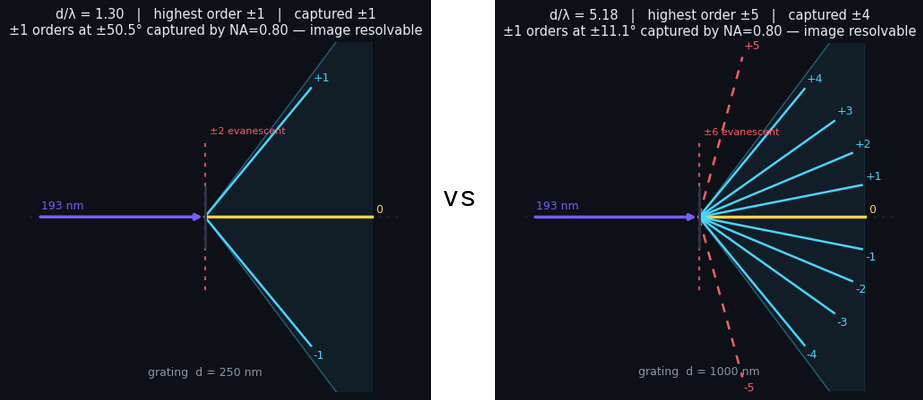

Please use the applet below to recreate these results.

`At face value it would appear the a smaller grating solves our issue. Since it makes capturing higher order diffration patterns dufficult, we get the 0th order and that is what we what. However studies of existing DUV pipelines showed that this is not the case. In fact, great effort is taken to try and capture the 1st order differentials. Capturing them is the whole purpose of the Diffractive Optical Element (DOE) and the Partial coherence factor (σ). We were clearly lacking a understanding of something.`

Something we we found in this video series - https://www.youtube.com/watch?v=_bhEDQzNQ-c

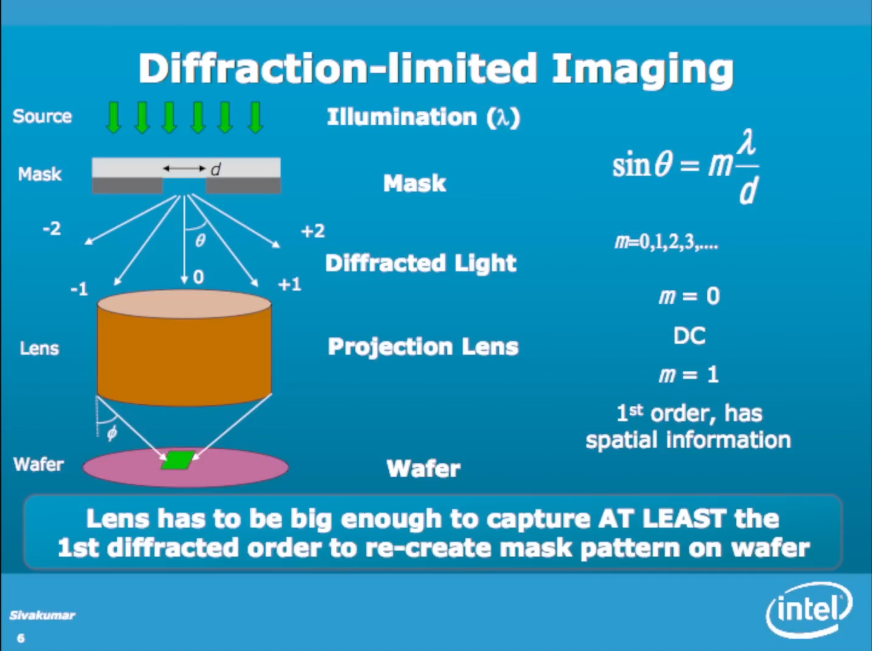

**Step 2 - Spatial Information**
<br>




For a periodic pattern, the diffraction-order (Fourier) picture underlying Abbe's resolution criterion shows that the 0th order — the light that passes straight through undiffracted — carries only the average transmitted intensity and no spatial/positional information about the slit pattern it passed through.

The positional information about the pitch is carried by the ±1 and higher orders, as shown in the spatial information expressed as a function of diffraction orders below.

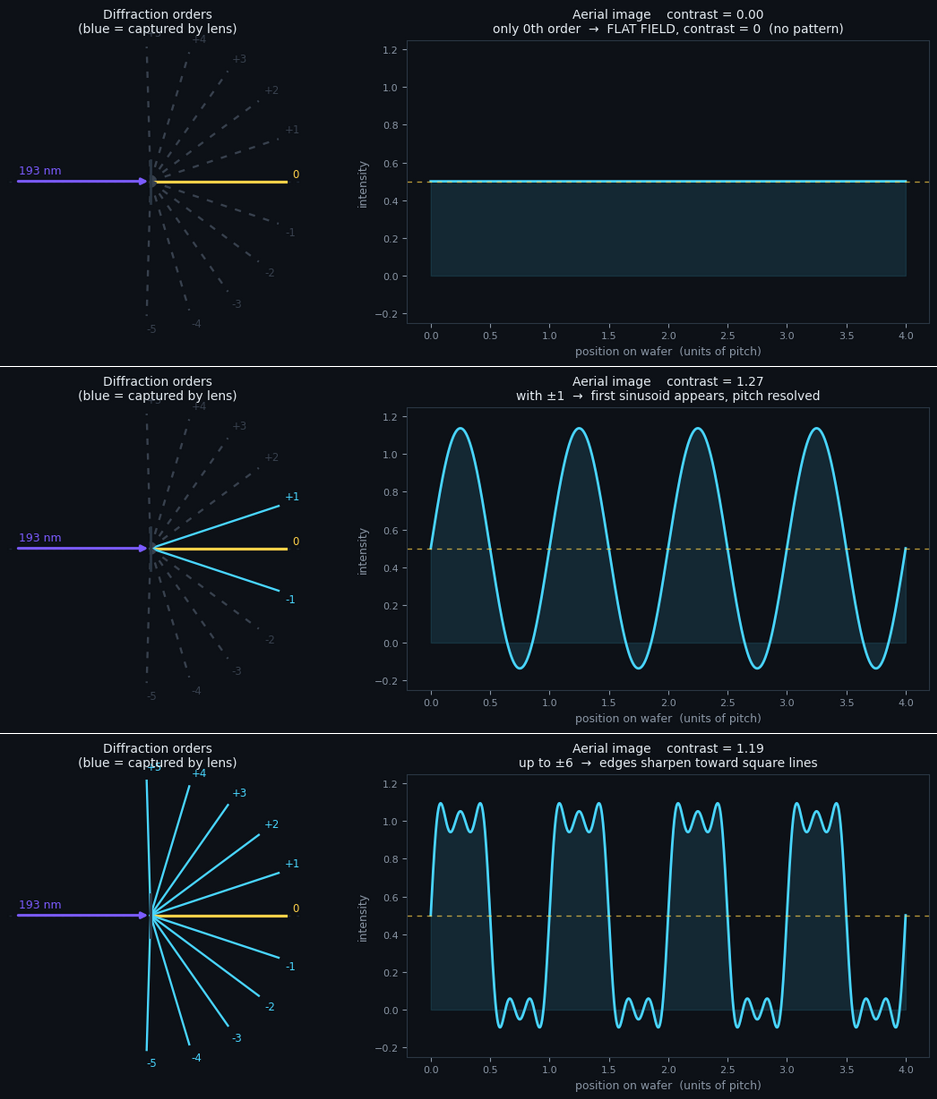

For Aperiodic patterns there are no discrete orders at all — the spectrum is continuous. So strictly, there's no "0th order" as a separate beam. What there is is the DC component: the value of the pattern's Fourier transform at spatial frequency zero, f = 0. And that single point in the continuous spectrum behaves exactly like the periodic 0th order — it encodes only the average/overall transmission and carries no spatial information. Spatial information lives entirely in the nonzero frequencies, periodic or not.

`Upon deeper investigation, it is clear that we need to capture at least one diffraction order if we want to transfer the retical pattern to the wafer. This is the minimum requirement and is subject to the NA of the projection lens, the wavelength of the light used and the CD of the reticle before demagnification.`



**Step 3 - DOE and σ**

Meeting the Rayleigh Criterion via the correct DOE (it extends resolution beyond the conventional limit for the matched orientation) and having the right sigma to meet Abbe's resolution (Aperiodic patterns with customizable σ) in a app clearly explains why we need both the DOE and σ and what physical phenomenon they are designed to counter to get the correct transfer of the retical pattern to the wafer. The projection lens (demagnifier) has been omitted for simplicity.


In [ ]:
# @title DUV Resolution Sandbox — Abbe & Rayleigh, NA and σ
# Colab has numpy/scipy/matplotlib/ipywidgets preinstalled.
# !pip install ipywidgets matplotlib scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
%matplotlib inline

LAMBDA = 193.0   # nm, ArF source (3 pm FWHM, fixed source condition)
N = 256
L = 3000.0
_x = (np.arange(N)-N/2)*(L/N)
X, Y = np.meshgrid(_x, _x)
_fx = np.fft.fftshift(np.fft.fftfreq(N, d=L/N))
FX, FY = np.meshgrid(_fx, _fx)
FR = np.hypot(FX, FY)


# ---------- analytic Airy two-point (NA / Rayleigh panel) ----------
def airy_psf(r, NA):
    v = 2*np.pi*NA*np.abs(r)/LAMBDA
    out = np.ones_like(v); nz = v != 0
    out[nz] = (2*j1(v[nz])/v[nz])**2
    return out

def two_point_airy(sep, NA, npts=1601):
    span = max(3*sep, 4*LAMBDA/NA)
    x = np.linspace(-span, span, npts)
    return x, airy_psf(x-sep/2, NA) + airy_psf(x+sep/2, NA)

def rayleigh_airy(sep, NA):
    _, I = two_point_airy(sep, NA)
    r = I[len(I)//2]/I.max()
    return r, r < 0.811

# ---------- partial-coherent Fourier (sigma / Abbe panels) ----------
def pupil(NA):
    return (FR <= NA/LAMBDA).astype(float)

def source(kind, NA, sigma):
    fcut = NA/LAMBDA
    if kind == 'conventional':
        return (FR <= sigma*fcut).astype(float)
    return ((FR >= 0.7*sigma*fcut) & (FR <= sigma*fcut)).astype(float)

def image_partial(obj, NA, src):
    P = pupil(NA); O = np.fft.fftshift(np.fft.fft2(obj))
    pts = np.argwhere(src > 0)
    if len(pts) == 0:
        return np.abs(np.fft.ifft2(np.fft.ifftshift(O*P)))**2
    step = max(1, len(pts)//50); used = pts[::step]; acc = np.zeros((N,N))
    for iy, ix in used:
        Pi = np.roll(np.roll(P, iy-N//2, 0), ix-N//2, 1)
        acc += np.abs(np.fft.ifft2(np.fft.ifftshift(O*Pi)))**2
    return acc/len(used)

def two_contacts(sep, w=25):
    o = np.ones((N,N))
    for cx in (-sep/2, +sep/2):
        o[(np.abs(X-cx) < w) & (np.abs(Y) < w)] = 0.0
    return o

def dip_ratio_pc(sep, NA, sigma, kind='conventional'):
    prof = image_partial(two_contacts(sep), NA, source(kind, NA, sigma))[N//2, :]
    pk = prof.max(); ctr = prof[N//2]
    return ctr/pk, (ctr/pk) < 0.81

def duv_sandbox(separation=150, NA=0.75, sigma=0.5, illum='conventional'):
    fig = plt.figure(figsize=(12, 7.2)); fig.patch.set_facecolor('#0d1117')
    gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.27)
    def style(a):
        a.set_facecolor('#0d1117')
        for s in a.spines.values(): s.set_color('#2b3744')
        a.tick_params(colors='#8b97a6', labelsize=7.5)

    # (1) NA / RAYLEIGH two-point (analytic Airy) -- DEMO 1
    ax1 = fig.add_subplot(gs[0,0]); style(ax1)
    xr, Ir = two_point_airy(separation, NA)
    ratio, resolved = rayleigh_airy(separation, NA)
    ax1.plot(xr, Ir/Ir.max(), color='#4ad6ff', lw=1.8)
    ax1.axvline(0, color='#ff5d6c', lw=0.8, ls=':')
    ax1.axhline(0.811, color='#ffd24a', lw=0.8, ls='--', alpha=0.7)
    ax1.text(xr[-1], 0.83, 'Rayleigh 0.81', color='#ffd24a', fontsize=7, ha='right')
    ax1.set_title(f'DEMO 1 \u2014 NA/Abbe lever (analytic Airy)\n'
                  f'sep={separation}nm  \u2192  {"RESOLVED" if resolved else "NOT resolved"} (dip/pk={ratio:.2f})',
                  color='#7CFC9B' if resolved else '#ff5d6c', fontsize=9.5)
    ax1.set_xlabel('x (nm)', color='#8b97a6', fontsize=7.5); ax1.set_ylim(0,1.05)

    # (2) Rayleigh separation vs NA -- the Abbe curve (DEMO 1 context)
    ax2 = fig.add_subplot(gs[0,1]); style(ax2)
    NAs = np.linspace(0.4, 1.4, 200)
    ax2.plot(NAs, 0.61*LAMBDA/NAs, color='#ffd24a', lw=1.8)
    ax2.axhline(separation, color='#4ad6ff', lw=1.2, ls='--')
    ax2.plot([NA], [0.61*LAMBDA/NA], 'o', color='#ff5d6c', ms=7)
    ax2.text(0.95, separation+8, f'your sep={separation}nm', color='#4ad6ff', fontsize=7.5)
    ax2.set_title('Rayleigh limit 0.61\u03bb/NA vs NA\nresolves when curve dips below your sep',
                  color='#e6edf3', fontsize=9.5)
    ax2.set_xlabel('NA', color='#8b97a6', fontsize=7.5)
    ax2.set_ylabel('resolvable sep (nm)', color='#8b97a6', fontsize=7.5)

    # (3) SIGMA lever: dip/peak vs sigma (partial coherent two-point) -- DEMO 2
    ax3 = fig.add_subplot(gs[1,0]); style(ax3)
    sigs = np.linspace(0.2, 0.95, 16)
    ratios = [dip_ratio_pc(separation, NA, sg, illum)[0] for sg in sigs]
    ax3.plot(sigs, ratios, '-o', color='#ffd24a', ms=3, lw=1.4)
    ax3.axhline(0.81, color='#ff5d6c', lw=0.8, ls='--', alpha=0.8)
    ax3.text(0.93, 0.82, 'resolve threshold', color='#ff5d6c', fontsize=7, ha='right')
    cur = dip_ratio_pc(separation, NA, sigma, illum)[0]
    ax3.plot([sigma], [cur], 'o', color='#4ad6ff', ms=8)
    ax3.invert_xaxis()
    ax3.set_title('DEMO 2 \u2014 \u03c3 lever (partial-coherent two-point)\n'
                  'lower \u03c3 \u2192 lower dip/peak \u2192 resolves',
                  color='#e6edf3', fontsize=9.5)
    ax3.set_xlabel('\u03c3   (\u2190 decreasing)', color='#8b97a6', fontsize=7.5)
    ax3.set_ylabel('dip/peak', color='#8b97a6', fontsize=7.5)

    # (4) ABBE pupil + source
    ax4 = fig.add_subplot(gs[1,1]); style(ax4)
    src = source(illum, NA, sigma); fcut = NA/LAMBDA
    obj = two_contacts(separation)
    O = np.abs(np.fft.fftshift(np.fft.fft2(obj))); O = np.log1p(O/O.max()*50)
    ax4.imshow(O, extent=[_fx[0],_fx[-1],_fx[0],_fx[-1]], cmap='magma', origin='lower')
    th = np.linspace(0,2*np.pi,120)
    ax4.plot(fcut*np.cos(th), fcut*np.sin(th), color='#4ad6ff', lw=1.5)
    sp = np.argwhere(src>0)
    if len(sp): ax4.scatter(_fx[sp[:,1]], _fx[sp[:,0]], s=4, color='#ffd24a', alpha=0.5)
    ax4.set_title(f'Abbe pupil & object spectrum\ncyan=NA cutoff (\u03bb/NA={LAMBDA/NA:.0f}nm), gold=source',
                  color='#e6edf3', fontsize=9.5)
    ax4.set_xlabel('fx (cyc/nm)', color='#8b97a6', fontsize=7.5)

    k1 = separation*NA/(2*LAMBDA)
    fig.suptitle(f'\u03bb=193nm   NA={NA:.2f}   \u03c3={sigma:.2f}   '
                 f'Rayleigh 0.61\u03bb/NA={0.61*LAMBDA/NA:.0f}nm   sep={separation}nm   k1\u2248{k1:.2f}',
                 color='#e6edf3', fontsize=10.5, y=0.99)
    plt.show()

interact(duv_sandbox,
    separation=IntSlider(min=80, max=300, step=5, value=150, description='sep (nm)', continuous_update=False),
    NA=FloatSlider(min=0.40, max=1.35, step=0.01, value=0.75, description='NA (Abbe)', continuous_update=False),
    sigma=FloatSlider(min=0.20, max=0.95, step=0.05, value=0.50, description='\u03c3 sigma', continuous_update=False),
    illum=Dropdown(options=['conventional','annular'], value='conventional', description='illum'));



**Summary**

One major challenge that we overcame was understanding both the physical phenomenon driving the need for Computational Lithography and understanding the role of DOE and σ in aiding the reticle transfer the correct image to the wafer. The CL tools implemented on the reticle (e.g. OPC, multi pattern exposure. etc) are know to compliment the DOE and σ. For simplicity, they have been ommitted from this report.

**Examples**

**Demo 1 - NA / Abbe rescues resolution.**

Fix two features at a fixed separation and raise the numerical aperture. As NA grows the Airy disks shrink (the Rayleigh separation 0.61λ/NA drops below the feature spacing) and the unresolved pair becomes resolved.

Settings:
sep = 150 nm,
σ = 0.5;
sweep NA 0.6 → 0.9. Crosses to resolved near NA 0.75.

# The Rayleigh Criterion

The **Rayleigh Criterion** specifies the minimum angular separation ($\theta$) required between two point light sources for them to be distinguished as separate entities by an optical system. Because light behaves as a wave, when it passes through a finite aperture (like a single slit or a circular lens), it does not form a perfectly sharp point on a screen. Instead, it diffracts and creates a characteristic intensity pattern with a wide central maximum flanked by narrower minima and secondary maxima.

According to Lord Rayleigh, two overlapping diffraction patterns are **just resolved** when:

> The central maximum of the diffraction pattern from the first source aligns exactly with the **first minimum** of the diffraction pattern from the second source.

For a single slit of width $d$ and light of wavelength $\lambda$, the position of the first minimum is given by:

$$\sin(\theta) = \frac{\lambda}{d}$$

### When the Slit Size Approaches the Wavelength

The general condition for the diffraction minima of a single slit is:

$$d \sin(\theta) = m\lambda \quad \text{where } m = \pm 1, \pm 2, \pm 3, \dots$$

Rearranging for the allowed angles of the diffraction orders ($m$):

$$\sin(\theta) = \frac{m\lambda}{d}$$

Because the value of $|\sin(\theta)|$ cannot exceed $1$, the maximum possible integer order $m_{\text{max}}$ that can physically emerge is bounded by:

$$m_{\text{max}} < \frac{d}{\lambda}$$

* **When $d \gg \lambda$:** Many diffraction orders fit within the physical boundary ($\sin(\theta) \le 1$), meaning light tightly concentrates in a sharp central peak with highly closely spaced fringes.
* **As $d \to \lambda$:** The denominator shrinks, causing $\sin(\theta)$ to grow larger for each order. The diffraction pattern aggressively spreads out. When $d$ becomes exactly equal to or smaller than $\lambda$, **even the first order ($m=1$) cannot exist** because $\sin(\theta) \ge 1$. At this limit, the central maximum spreads across the entire $180^\circ$ plane ($\theta = \pm 90^\circ$), and distinct diffraction orders completely vanish into a single uniform wave expansion.

###1. Why resolution has a limit
Light passing any aperture or periodic structure **diffracts** — it spreads instead of
casting a sharp shadow. A point source imaged through a circular lens forms not a point
but an **Airy pattern**: a bright central disk plus faint rings. The size of that disk
sets how close two features can be and still be distinguished.

### 2. The Rayleigh criterion
Two equally bright points are *just* resolved when the central maximum of one Airy
pattern sits on the first minimum of the other:

$$ \sin\theta_R = 1.22\,\frac{\lambda}{D} $$

In imaging terms, with numerical aperture $\mathrm{NA}=n\sin\theta$, this becomes the
form used in lithography:

$$ \boxed{\,\mathrm{CD}_{\min}=k_1\,\frac{\lambda}{\mathrm{NA}}\,} $$

$k_1$ is a process factor ($0.61$ for the textbook limit, down to ~$0.25$ in real fabs
with resolution enhancement). Resolution improves with shorter $\lambda$ and larger NA,
and degrades as features approach $\lambda/\mathrm{NA}$.

### 3. Diffraction from a grating
A reticle of pitch $d$ acts as a grating, splitting the incident wave into orders:

$$ d\,\sin\theta_m = m\,\lambda,\qquad m=0,\pm1,\pm2,\dots $$

The 0th order carries average brightness but no pitch information; the **±1 orders**
carry the fundamental periodicity. The lens must capture **at least the 0th and one
1st order** to reconstruct the pattern. As $d\to\lambda$: the orders diffract at larger
angles, swing **outside the acceptance cone** ($\theta_m>\theta_{\max}$, $\sin\theta_{\max}=\mathrm{NA}$),
and once $d<\lambda$ the ±1 orders become **evanescent** and never propagate. That is the
regime where off-axis illumination, $\sigma$ tuning, SMO, and higher NA are deployed.


More : https://www.youtube.com/watch?v=YAMmhTexnS0

In [1]:
# @title The Rayleigh Criterion and Diffraction Orders
# Colab has ipywidgets + matplotlib preinstalled. If running elsewhere:
# !pip install ipywidgets matplotlib
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
%matplotlib inline

LAMBDA = 193.0   # nm, ArF source
DLAMBDA = 3e-3   # 3 pm FWHM, shown as a fixed source condition

def diffraction_angles(pitch_nm, lam=LAMBDA):
    """Propagating order angles (radians) for grating pitch (nm)."""
    out, m = [], 0
    while abs(m * lam / pitch_nm) <= 1.0:
        out.append((m, np.arcsin(m * lam / pitch_nm)))
        m += 1
    return out


def show(pitch=600, NA=0.90):
    lam = LAMBDA
    theta_max = np.arcsin(min(NA, 1.0))
    orders = diffraction_angles(pitch, lam)
    m_max = orders[-1][0]
    captured = max([m for (m, th) in orders if m != 0 and abs(th) <= theta_max], default=0)

    fig, ax = plt.subplots(figsize=(9, 4.6))
    ax.set_facecolor('#0d1117'); fig.patch.set_facecolor('#0d1117')
    L = 1.0  # ray length

    # optical axis
    ax.axhline(0, color='#1e2733', lw=1, ls=(0, (2, 5)))

    # lens acceptance cone (to the right)
    ax.fill_between([0, L], [0, L*np.tan(theta_max)], [0, -L*np.tan(theta_max)],
                    color='#4ad6ff', alpha=0.07, zorder=0)
    ax.plot([0, L], [0,  L*np.tan(theta_max)], color='#4ad6ff', alpha=0.35, lw=1)
    ax.plot([0, L], [0, -L*np.tan(theta_max)], color='#4ad6ff', alpha=0.35, lw=1)

    # incident beam
    ax.annotate('', xy=(0, 0), xytext=(-L, 0),
                arrowprops=dict(arrowstyle='-|>', color='#7c5cff', lw=2.5))
    ax.text(-L*0.98, 0.05, '193 nm', color='#7c5cff', fontsize=9)

    # diffracted orders
    for m, th in orders:
        for sign in ([0] if m == 0 else [+1, -1]):
            t = sign * th
            x2, y2 = L*np.cos(t), L*np.sin(t)
            is_cap = (m != 0) and (abs(th) <= theta_max)
            col = '#ffd24a' if m == 0 else ('#4ad6ff' if is_cap else '#ff5d6c')
            ls = '-' if (m == 0 or is_cap) else (0, (4, 4))
            ax.plot([0, x2], [0, y2], color=col, lw=2.4 if m == 0 else 1.8, ls=ls)
            lbl = '0' if m == 0 else f'{"+" if sign>0 else "-"}{m}'
            ax.text(x2*1.02, y2*1.02 + (0.03 if sign >= 0 else -0.06), lbl,
                    color=col, fontsize=9)

    # evanescent stub for first cut-off order
    s_ev = (m_max + 1) * lam / pitch
    if s_ev > 1:
        for sg in (+1, -1):
            ax.plot([0, 0], [0, sg*0.45], color='#ff5d6c', lw=1.6, ls=(0, (2, 3)), alpha=0.8)
        ax.text(0.03, 0.5, f'±{m_max+1} evanescent', color='#ff5d6c', fontsize=8)

    # grating marker
    ax.plot([0, 0], [-0.18, 0.18], color='#2b3744', lw=2)
    ax.text(0, -0.95, f'grating  d = {pitch} nm', color='#8b97a6',
            fontsize=9, ha='center')

    if m_max == 0:
        msg = f'd<\u03bb: only the 0th order propagates \u2014 grating UNRESOLVABLE'
    elif captured == 0:
        msg = (f'\u00b11 orders at \u00b1{np.degrees(orders[1][1]):.1f}\u00b0 fall OUTSIDE '
               f'NA={NA:.2f} \u2014 image has no contrast')
    else:
        msg = (f'\u00b11 orders at \u00b1{np.degrees(orders[1][1]):.1f}\u00b0 captured by '
               f'NA={NA:.2f} \u2014 image resolvable')
    ax.set_title(f'd/\u03bb = {pitch/lam:.2f}   |   highest order \u00b1{m_max}   |   '
                 f'captured \u00b1{captured}\n{msg}',
                 color='#e6edf3', fontsize=10.5)

    ax.set_xlim(-L*1.05, L*1.18); ax.set_ylim(-1.05, 1.05)
    ax.set_aspect('equal'); ax.axis('off')
    plt.tight_layout(); plt.show()

interact(show,
         pitch=IntSlider(min=100, max=2000, step=5, value=600,
                         description='pitch d (nm)', continuous_update=False),
         NA=FloatSlider(min=0.10, max=1.35, step=0.01, value=0.90,
                        description='lens NA', continuous_update=False));


# The Abbe Resolution Limit

The Abbe resolution limit, formulated by Ernst Abbe in 1873 from his work on microscope optics, defines the finest periodic structure an imaging system can resolve in terms of diffraction. When light illuminates a periodic object such as a grating, the object diffracts it into discrete orders at angles set by the grating equation,

$$ d\,\sin\theta = m\,\lambda $$

where $d$ is the pitch ( center-to-center spacing of a repeating pattern ), $\lambda$ the wavelength, and $m$ the order number.

Abbe's insight was that image formation is an interference process: to reconstruct the periodic structure, the imaging lens must collect at least two diffracted orders — at minimum the 0th order and one 1st order. The 0th order alone carries only the average transmitted intensity and forms a uniform, featureless field; without a 1st order entering the aperture, there is nothing for it to interfere with and no periodic information reaches the image.

This sets a hard limit on resolvable pitch. The lens can only capture an order if that order's diffraction angle falls within its acceptance cone, whose half-angle $\theta_{\max}$ is fixed by the numerical aperture,

$$ \mathrm{NA} = n\,\sin\theta_{\max} $$

As the pitch shrinks, the 1st-order diffraction angle grows; once it exceeds $\theta_{\max}$ the order is lost and the structure can no longer be resolved. The minimum resolvable pitch under conventional (on-axis) illumination is therefore

$$ d_{\min} = \frac{\lambda}{\mathrm{NA}} $$

and with two-beam or off-axis illumination, which lets the lens straddle the 0th and 1st orders symmetrically, this improves by a factor of two to

$$ d_{\min} = \frac{\lambda}{2\,\mathrm{NA}} $$

The Abbe limit is the diffraction-side counterpart to the Rayleigh criterion: Rayleigh describes resolution in terms of overlapping point-source blur in the image plane, while Abbe describes it in terms of which diffraction orders the aperture admits. Both yield the same scaling — resolution improves with shorter wavelength and higher NA — and differ only in the leading constant. In lithography this principle is the physical root of the resolution equation

$$ \mathrm{CD} = k_1\,\frac{\lambda}{\mathrm{NA}} $$

where k1 is a dimensionless process factor

It explains why 193 nm systems moved to immersion (raising NA above 1 by replacing air with water, $n \approx 1.44$) and why off-axis illumination, $\sigma$ optimization, and source–mask optimization are used to keep the critical diffraction orders inside the pupil as feature pitches are driven toward and below the wavelength.

With an aperiodic pattern — an isolated line, a contact hole, a random logic layout — has no single pitch. Instead of a Fourier series it has a continuous Fourier transform: its energy is spread across a continuum of spatial frequencies rather than concentrated into discrete orders. So instead of light diffracting into neat ±1 spots, it spreads into a continuous distribution of angles. There's no "1st order" to point at.

But the underlying resolution principle still holds — you just restate it in terms of spatial frequency:

The lens still acts as a low-pass filter. Its NA defines a maximum spatial frequency it can collect: f_max = NA/λ (the cutoff frequency). Any detail in the pattern whose spatial frequency exceeds that cutoff is simply not transmitted to the image, periodic or not. For a periodic pattern, "does the ±1 order fit in the pupil?" is the same question as "is the fundamental spatial frequency below the cutoff?" — the discrete case is just the continuous case sampled at one frequency.


For periodic features, resolution is naturally expressed as a minimum pitch

$$d_min = λ/2NA$$

because the pattern has a defined period and diffracts into discrete orders.

For aperiodic features, the same physics is expressed as a cutoff spatial frequency

$$f_max = NA/λ$$

or, in real-space terms, a minimum resolvable feature size / point-spread-function width. The lens passes everything below the cutoff and blocks everything above it.

This is also why isolated and dense features of the "same" CD don't print identically — the iso-dense bias. An isolated feature's energy is spread across many frequencies that interact with the pupil edge differently than a dense feature's concentrated orders, so they image with different effective sizes and process windows. That mismatch is one of the main things OPC (optical proximity correction) is built to fix — it's a direct, practical consequence of the difference you're asking about.

So: the pitch/order formulation is periodic-only, but the resolution limit itself is universal once you express it as a spatial-frequency cutoff

More: https://www.youtube.com/watch?v=Kj4zk91TVwo&t=782s

In [2]:
# @title Abbe Resolution
# Colab has numpy/matplotlib/ipywidgets preinstalled.
# !pip install ipywidgets matplotlib   # if running elsewhere
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
%matplotlib inline

LAMBDA = 193.0  # nm, ArF source, 3 pm FWHM (fixed source condition)


def aerial_image(captured_m, period=1.0, npts=1600, n_periods=4):
    """Reconstruct a 50%-duty line/space image from orders 0..captured_m.
    Square-wave Fourier series: DC=0.5 + odd harmonics 2/(m*pi)."""
    x = np.linspace(0, n_periods*period, npts)
    f = np.full_like(x, 0.5)              # 0th order = DC = flat field
    for m in range(1, captured_m+1):
        if m % 2 == 1:                    # square wave has only odd harmonics
            f += (2/(m*np.pi))*np.sin(2*np.pi*m*x/period)
    return x, f

def show(highest_captured=0):
    x, img = aerial_image(highest_captured)
    contrast = (img.max()-img.min())/(img.max()+img.min()+1e-9)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2),
                                   gridspec_kw={'width_ratios':[1, 1.4]})
    for a in (axL, axR):
        a.set_facecolor('#0d1117')
    fig.patch.set_facecolor('#0d1117')

    # ---- LEFT: orders + which are captured ----
    axL.axhline(0, color='#1e2733', lw=1, ls=(0,(2,5)))
    axL.annotate('', xy=(0,0), xytext=(-1,0),
                 arrowprops=dict(arrowstyle='-|>', color='#7c5cff', lw=2.2))
    axL.text(-0.98, 0.06, '193 nm', color='#7c5cff', fontsize=9)
    # show orders 0..5 at illustrative spreading angles
    spread = 0.32
    for m in range(0, 6):
        for sign in ([0] if m==0 else [+1,-1]):
            ang = sign*m*spread
            x2, y2 = np.cos(ang), np.sin(ang)
            cap = (m <= highest_captured)
            col = '#ffd24a' if m==0 else ('#4ad6ff' if cap else '#39424f')
            ls  = '-' if cap else (0,(3,4))
            axL.plot([0,x2],[0,y2], color=col, lw=2.3 if m==0 else 1.7, ls=ls)
            lab = '0' if m==0 else f'{"+" if sign>0 else "-"}{m}'
            axL.text(x2*1.05, y2*1.05+(0.03 if sign>=0 else -0.07), lab,
                     color=col, fontsize=8.5)
    axL.plot([0,0],[-0.16,0.16], color='#2b3744', lw=2)
    axL.set_title('Diffraction orders\n(blue = captured by lens)',
                  color='#e6edf3', fontsize=10)
    axL.set_xlim(-1.05,1.15); axL.set_ylim(-1.05,1.05)
    axL.set_aspect('equal'); axL.axis('off')

    # ---- RIGHT: reconstructed aerial image ----
    axR.plot(x, img, color='#4ad6ff', lw=2)
    axR.fill_between(x, 0, img, color='#4ad6ff', alpha=0.12)
    axR.axhline(0.5, color='#ffd24a', lw=1, ls=(0,(4,4)), alpha=0.7)
    axR.set_ylim(-0.25, 1.25)
    axR.set_xlabel('position on wafer  (units of pitch)', color='#8b97a6', fontsize=9)
    axR.set_ylabel('intensity', color='#8b97a6', fontsize=9)
    axR.tick_params(colors='#8b97a6', labelsize=8)
    for s in axR.spines.values(): s.set_color('#2b3744')
    if highest_captured == 0:
        sub = 'only 0th order  \u2192  FLAT FIELD, contrast = 0  (no pattern)'
    elif highest_captured == 1:
        sub = 'with \u00b11  \u2192  first sinusoid appears, pitch resolved'
    else:
        sub = f'up to \u00b1{highest_captured}  \u2192  edges sharpen toward square lines'
    axR.set_title(f'Aerial image    contrast = {contrast:.2f}\n{sub}',
                  color='#e6edf3', fontsize=10)

    plt.tight_layout(); plt.show()

interact(show,
         highest_captured=IntSlider(min=0, max=9, step=1, value=0,
                                    description='max order',
                                    continuous_update=False));


In [ ]:
be